# Data Preparation

1. **Load necessary data files**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_generators = pd.read_csv("data/powerplants.csv")

nodes = ["NO1", "NO2", "NO3", "NO4", "NO5"] #We define our problem over the 5 electrical zones in Norway

#Data that displays which generator types exist in each node
generators_data = pd.read_excel("Data/Sets.xlsx", sheet_name = "GeneratorsOfNode", skiprows=2)

#Initial capacity for each node and generator type combination
gen_capacities_data = pd.read_excel(
    "Data/Generator.xlsx",
    sheet_name="RefInitialCap",
    skiprows=2,
    usecols=["Node", "GeneratorTechnology", "generatoReferenceInitialCapacity in MW"]
)

#Investment cost for generators --> Does not include costs for maintaining installed capacity
inv_cost_gen_data = pd.read_excel("Data/Generator.xlsx", sheet_name = "CapitalCosts", skiprows = 2)

#Variable cost for generators
var_cost_gen_data = pd.read_excel("Data/Generator.xlsx", sheet_name = "VariableOMCosts", skiprows = 2)
fuel_cost_gen_data = pd.read_excel("Data/Generator.xlsx", sheet_name = "FuelCosts", skiprows = 2)

#Initial capacity of each transmission line
trans_capacities_data = pd.read_excel("Data/Transmission.xlsx", sheet_name = "InitialCapacity", skiprows = 2)

#Investment cost for transmission lines
inv_cost_trans_data = pd.read_excel(
    "Data/Transmission.xlsx",
    sheet_name = "TypeCapitalCost",
    skiprows = 2,
    usecols=["Type","Period","TypeCapitalCost in euro per MWkm"]
)

#Efficiency of directional flow a
dir_line_eff_data = pd.read_excel("Data/Transmission.xlsx", sheet_name = "lineEfficiency", skiprows = 2)

#Value of lost load
val_ll_data = pd.read_excel("Data/Node.xlsx", sheet_name = "NodeLostLoadCost", skiprows = 2)

#Hydro max annual production --> Node/HydroGenMaxAnnualProduction
hydr_max_annual_data = pd.read_excel("Data/Node.xlsx", sheet_name = "HydroGenMaxAnnualProduction", skiprows=2)

#Max installed capacity V --> Generator/MaxInstalledCapacity
max_inst_cap_data = pd.read_excel(
    "Data/Generator.xlsx",
    sheet_name = "MaxInstalledCapacity", 
    skiprows=2,
    usecols=["Node", "GeneratorTechnology", "generatorMaxInstallCapacity  in MW"]
)

#Electrical demand
demands_data = pd.read_csv("Data/electricload.csv")

#----------------Scenario data-------------------------------------------------

#Maximum available capacity of installed capacity og generator type in any given hour
solar_avail_cap_data = pd.read_csv("Data/solar.csv")
hydroror_avail_cap_data = pd.read_csv("Data/hydroror.csv")
windonshore_data = pd.read_csv("Data/windonshore.csv")

2. **Check Data for Missing Values**

We go through each dataset and check that there are no missing values. Doing this also displays the column names in each of the datasets.

In [12]:
#Check for missing values
print(gen_capacities_data.isna().sum())

Node                                      0
GeneratorTechnology                       0
generatoReferenceInitialCapacity in MW    0
dtype: int64


In [13]:
print(trans_capacities_data.isna().sum())

InterconnectorLinks            0
ToNode                         0
Period                         0
TransmissionInitialCapacity    0
dtype: int64


In [14]:
print(inv_cost_gen_data.isna().sum())

GeneratorTechnology                    0
Period                                 0
generatorCapitalCost in euro per kW    0
dtype: int64


In [15]:
print(inv_cost_trans_data.isna().sum())

Type                                0
Period                              0
TypeCapitalCost in euro per MWkm    0
dtype: int64


In [16]:
print(var_cost_gen_data.isna().sum())

GeneratorTechnology                         0
generatorVariableOMcosts in euro per MWh    0
dtype: int64


In [17]:
print(fuel_cost_gen_data.isna().sum())

GeneratorTechnology                     0
Period                                  0
generatorTypeFuelCost in euro per GJ    0
dtype: int64


In [18]:
print(val_ll_data.isna().sum())

Nodes               0
Period              0
NodeLostLoadCost    0
dtype: int64


In [19]:
print(dir_line_eff_data.isna().sum())

FromNode          0
ToNode            0
lineEfficiency    0
dtype: int64


In [20]:
print(hydr_max_annual_data.isna().sum())

Nodes                                          0
HydroGenMaxAnnualProduction in MWh per year    0
dtype: int64


In [21]:
print(max_inst_cap_data.isna().sum())

Node                                  0
GeneratorTechnology                   0
generatorMaxInstallCapacity  in MW    0
dtype: int64


3. **Remove Data Not Necessary for the Model**

In [22]:
#Remove everything not related to the 5 Norwegian nodes/all irrelevant data

generators = generators_data[
    generators_data["Node"].isin(nodes)
].copy()

#Initial generation capacity
gen_capacities = gen_capacities_data[
    gen_capacities_data["Node"].isin(nodes)
].copy()

#Initial transmission capacity
trans_capacities = trans_capacities_data[
    (trans_capacities_data["Period"] == 1)
    &
    (
        trans_capacities_data["InterconnectorLinks"].isin(nodes)
        |
        trans_capacities_data["ToNode"].isin(nodes)
    )
].copy()
trans_capacities = trans_capacities.drop(columns=["Period"]) #Drop unneccesary period column

#Investment costs for generators
inv_cost_gen = inv_cost_gen_data[
    inv_cost_gen_data["Period"] == 1
].copy()
inv_cost_gen = inv_cost_gen.drop(columns=["Period"]) #Drop unneccesary period column

#Investment costs for transmission
inv_cost_trans = inv_cost_trans_data[
    inv_cost_trans_data["Period"] == 1
].copy()
inv_cost_trans = inv_cost_trans.drop(columns=["Period"]) #Drop unneccesary period column

#Fuel costs for generators
fuel_cost_gen = fuel_cost_gen_data[
    fuel_cost_gen_data["Period"] == 1
].copy()
fuel_cost_gen = fuel_cost_gen.drop(columns=["Period"]) #Drop unneccesary period column

#Value of lost load
val_ll = val_ll_data[
    val_ll_data["Nodes"].isin(nodes)
].copy()
val_ll = val_ll.drop(columns=["Period"]) #Drop unneccesary period column

#Maximum regulated hydro
hydr_max_annual = hydr_max_annual_data[
    hydr_max_annual_data["Nodes"].isin(nodes)
].copy()

#Maximum installed capacity
max_inst_cap = max_inst_cap_data[
    max_inst_cap_data["Node"].isin(nodes)
].copy()

#Line efficiency
dir_line_eff = dir_line_eff_data[
    (
        dir_line_eff_data["FromNode"].isin(nodes)
        |
        dir_line_eff_data["ToNode"].isin(nodes)
    )
].copy()

#Demand
demands = demands_data[
    ["NO1", "NO2", "NO3", "NO4", "NO5", "time", "hour", "dayofweek","month"]
].copy()

**Display Historic Demand Data**

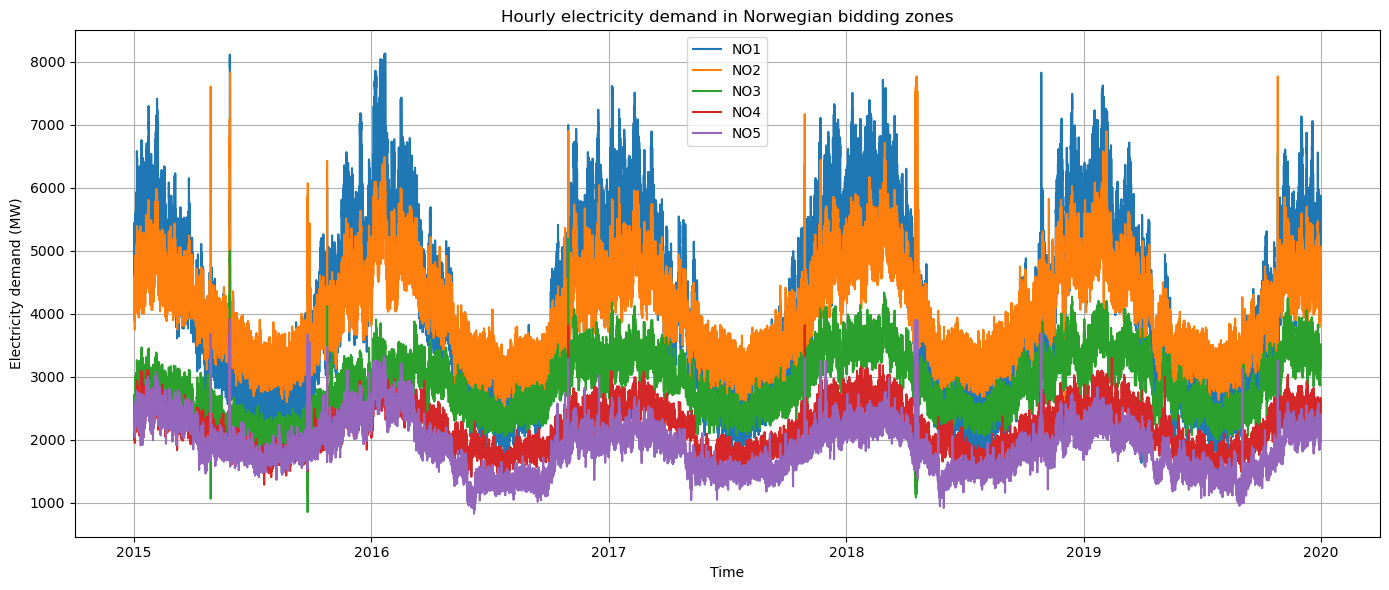

In [23]:
demands["time"] = pd.to_datetime(
    demands["time"],
    dayfirst=True
)

plt.figure(figsize=(14, 6))

for node in ["NO1", "NO2", "NO3", "NO4", "NO5"]:
    plt.plot(
        demands["time"],
        demands[node],
        label=node
    )

plt.xlabel("Time")
plt.ylabel("Electricity demand (MW)")
plt.title("Hourly electricity demand in Norwegian bidding zones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='Node'>

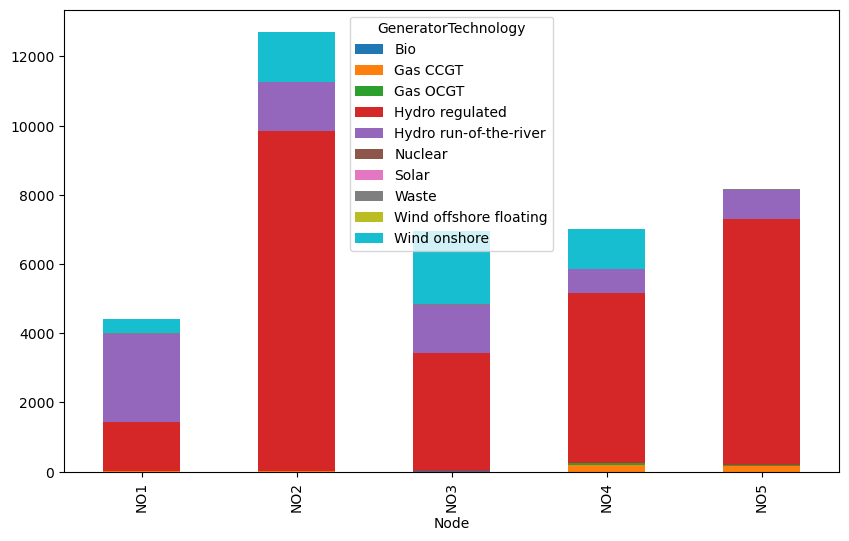

In [24]:
capacity_by_node = (
    gen_capacities
    .groupby(["Node", "GeneratorTechnology"])
    ["generatoReferenceInitialCapacity in MW"]
    .sum()
    .reset_index()
)

capacity_by_node.pivot(
    index="Node",
    columns="GeneratorTechnology",
    values="generatoReferenceInitialCapacity in MW"
).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

4. **Transform Data to Fit Model Scope**

In [25]:
#From the generators-data we can create the sets we need for the model, G and G_n
G = generators["Generator"].unique().tolist()
G_n = (
    generators
    .groupby("Node")["Generator"]
    .unique()
    .apply(list)
    .to_dict()
)

# The initial capacities should be aggregated to only exist per generation technology, not per generation technology + node combo
gen_capacities_aggregated = (
    gen_capacities
    .groupby("GeneratorTechnology")["generatoReferenceInitialCapacity in MW"]
    .sum()
    .reset_index()
)

#From inspecting the dataset we can see that there are some technologies in the set G that are not present in gen_capacities_aggregated
#We add these to the inital capacities table with value 0
gen_capacities_aggregated = (
    gen_capacities
    .groupby("GeneratorTechnology")["generatoReferenceInitialCapacity in MW"]
    .sum()
    .reset_index()
)

gen_capacities_aggregated = (
    gen_capacities_aggregated
    .set_index("GeneratorTechnology")
    .reindex(G)
    .fillna(0)
    .reset_index()
)
# inv_cost_gen displays the cost in Euros per 1kW capacity invested --> we want this in MW to match the other datasets
inv_cost_gen["generatorCapitalCost in euro per MW"] = (
    inv_cost_gen["generatorCapitalCost in euro per kW"] * 1000
)

#The total variable costs of operating a generation technology is the sum of its respective value from the variable cost data and the fuel cost data
#The variable cost table is measured in cost per MWh, whilst the fuel cost is per GJ, we convert this to MWh before summing them
fuel_cost_gen["generatorTypeFuelCost in euro per MWh"] = (
    fuel_cost_gen["generatorTypeFuelCost in euro per GJ"] * 3.6
)

var_cost_gen_data["GeneratorTechnology"] = (
    var_cost_gen_data["GeneratorTechnology"]
    .astype(str)
    .str.strip()
)

fuel_cost_gen["GeneratorTechnology"] = (
    fuel_cost_gen["GeneratorTechnology"]
    .astype(str)
    .str.strip()
)

total_variable_cost = pd.merge(
    var_cost_gen_data[["GeneratorTechnology", "generatorVariableOMcosts in euro per MWh"]],
    fuel_cost_gen[["GeneratorTechnology", "generatorTypeFuelCost in euro per MWh"]],
    on="GeneratorTechnology",
    how="outer"
)

total_variable_cost["TotalVariableCost in euro per MWh"] = (
    total_variable_cost["generatorVariableOMcosts in euro per MWh"]
    + total_variable_cost["generatorTypeFuelCost in euro per MWh"]
)

5. **Data Visualization**

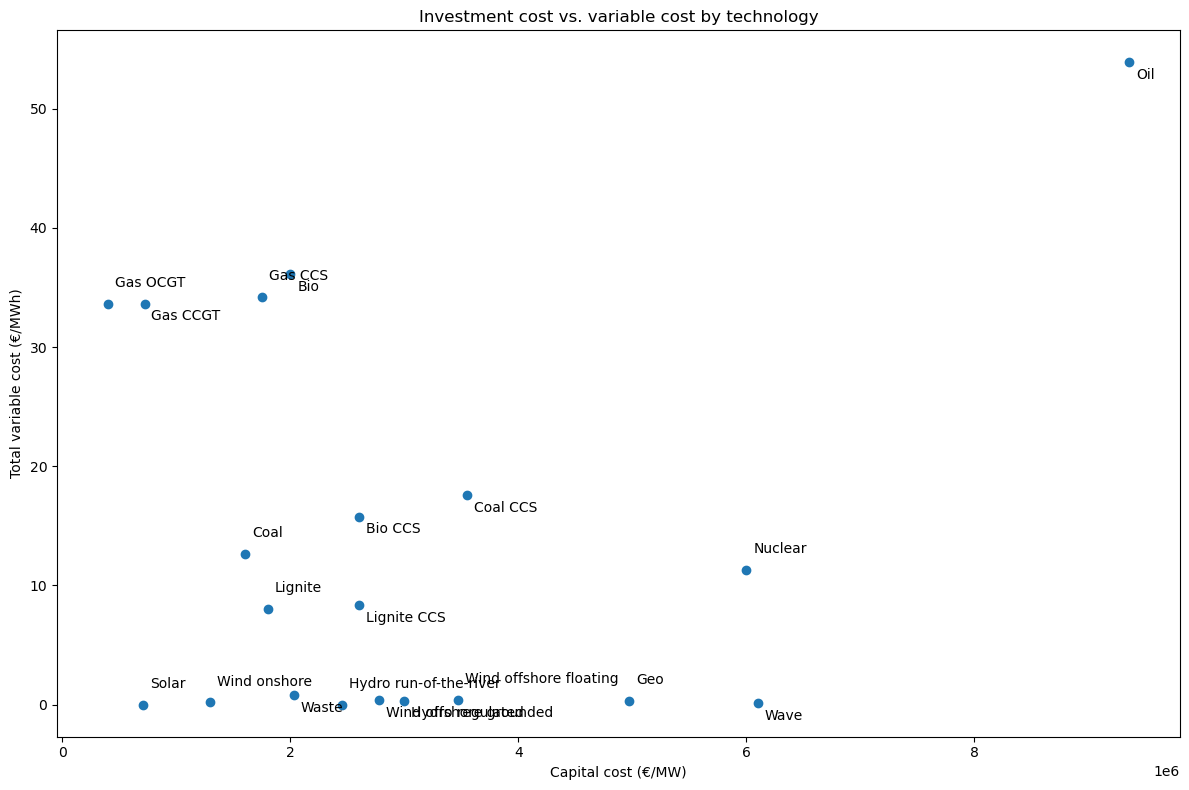

In [26]:
#COST DATA VISUALIZATION
technology_costs = (
    inv_cost_gen[
        ["GeneratorTechnology", "generatorCapitalCost in euro per MW"]
    ]
    .merge(
        total_variable_cost[
            ["GeneratorTechnology", "TotalVariableCost in euro per MWh"]
        ],
        on="GeneratorTechnology",
        how="inner"
    )
)

plt.figure(figsize=(12, 8))

plt.scatter(
    technology_costs["generatorCapitalCost in euro per MW"],
    technology_costs["TotalVariableCost in euro per MWh"]
)

for i, (_, row) in enumerate(technology_costs.iterrows()):
    offset = (5, 12) if i % 2 == 0 else (5, -12)

    plt.annotate(
        row["GeneratorTechnology"],
        (
            row["generatorCapitalCost in euro per MW"],
            row["TotalVariableCost in euro per MWh"]
        ),
        xytext=offset,
        textcoords="offset points"
    )

plt.xlabel("Capital cost (€/MW)")
plt.ylabel("Total variable cost (€/MWh)")
plt.title("Investment cost vs. variable cost by technology")
plt.tight_layout()
plt.show()

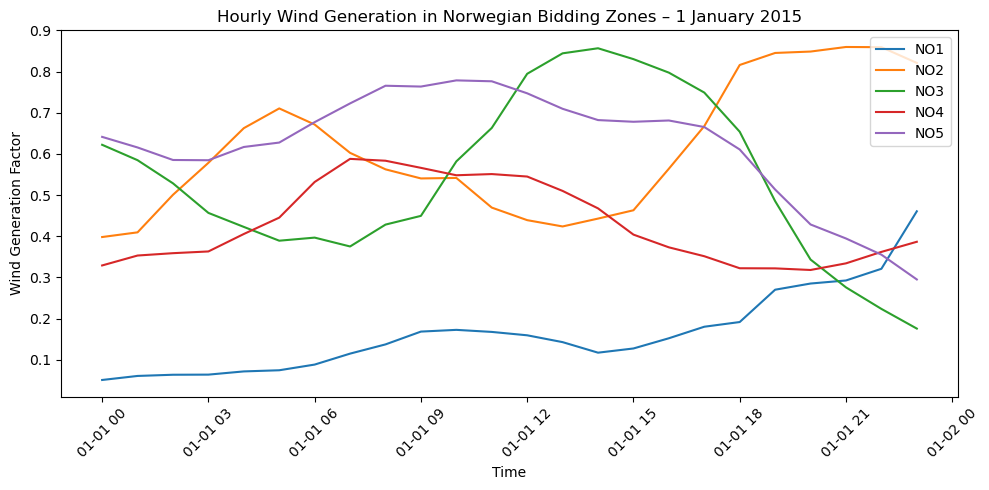

In [31]:
# WIND DATA VISUALIZATION (1 JANUARY 2015)

# Convert time to datetime
windonshore_data["time"] = pd.to_datetime(windonshore_data["time"], dayfirst=True)

first_day = windonshore_data[
    windonshore_data["time"].dt.date == pd.Timestamp("2015-01-01").date()
].copy()

# Plot
plt.figure(figsize=(10, 5))

for zone in nodes:
    plt.plot(first_day["time"], first_day[zone], label=zone)

plt.xlabel("Time")
plt.ylabel("Wind Generation Factor")
plt.title("Hourly Wind Generation in Norwegian Bidding Zones – 1 January 2015")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()